In [227]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks


In [228]:

# Load the dataset
df = pd.read_csv("/content/Train_Test_IoT_Thermostat.csv")


In [229]:

# Data Exploration and Preprocessing
print("Initial DataFrame:")
print(df.head())



Initial DataFrame:
        date     time  current_temperature  thermostat_status  label  \
0  25-Apr-19  8:59:02            30.577325                  1      1   
1  25-Apr-19  8:59:06            29.187912                  1      1   
2  25-Apr-19  8:59:06            30.208893                  1      1   
3  25-Apr-19  8:59:06            27.731392                  1      1   
4  25-Apr-19  8:59:06            26.211462                  1      1   

        type  
0  injection  
1  injection  
2  injection  
3  injection  
4  injection  


In [230]:
print("\nDataFrame Info:")
df.info()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32774 entries, 0 to 32773
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 32774 non-null  object 
 1   time                 32774 non-null  object 
 2   current_temperature  32774 non-null  float64
 3   thermostat_status    32774 non-null  int64  
 4   label                32774 non-null  int64  
 5   type                 32774 non-null  object 
dtypes: float64(1), int64(2), object(3)
memory usage: 1.5+ MB


In [231]:
df['type'].unique()

array(['injection', 'backdoor', 'normal', 'password', 'ransomware',
       'scanning', 'xss'], dtype=object)

In [232]:
df['type'].value_counts()

,count
type,
normal,15000
injection,5000
backdoor,5000
password,5000
ransomware,2264
xss,449
scanning,61


In [233]:
df

,date,time,current_temperature,thermostat_status,label,type
0,25-Apr-19,8:59:02,30.577325,1,1,injection
1,25-Apr-19,8:59:06,29.187912,1,1,injection
2,25-Apr-19,8:59:06,30.208893,1,1,injection
3,25-Apr-19,8:59:06,27.731392,1,1,injection
4,25-Apr-19,8:59:06,26.211462,1,1,injection
...,...,...,...,...,...,...
32769,27-Apr-19,05:40:25,25.000000,0,1,xss
32770,27-Apr-19,05:40:30,26.011628,1,1,xss
32771,27-Apr-19,05:40:40,30.093672,1,1,xss
32772,27-Apr-19,05:40:43,25.000000,0,1,xss


In [234]:

import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# Strip spaces from date and time columns
df['date'] = df['date'].astype(str).str.strip()
df['time'] = df['time'].astype(str).str.strip()

# Try parsing with mixed formats automatically
df['datetime'] = pd.to_datetime(
    df['date'] + ' ' + df['time'],
    format='mixed',  # lets pandas handle inconsistent formats
    errors='coerce'  # replaces invalid formats with NaT
)

# Drop rows where datetime couldn't be parsed (if any)
df = df.dropna(subset=['datetime'])

# Drop old columns
df = df.drop(['date', 'time'], axis=1)

# Encode categorical features
categorical_cols = ['type']
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    joblib.dump(le, f'{col}_encoder.pkl')



#

print("\n✅ DataFrame after preprocessing:")
display(df.head())



✅ DataFrame after preprocessing:


,current_temperature,thermostat_status,label,type,datetime
0,30.577325,1,1,1,2019-04-25 08:59:02
1,29.187912,1,1,1,2019-04-25 08:59:06
2,30.208893,1,1,1,2019-04-25 08:59:06
3,27.731392,1,1,1,2019-04-25 08:59:06
4,26.211462,1,1,1,2019-04-25 08:59:06


In [235]:
df.isna().sum()

,0
current_temperature,0
thermostat_status,0
label,0
type,0
datetime,0


In [236]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, utils
from collections import Counter


In [237]:
df['hour'] = df['datetime'].dt.hour
df['day'] = df['datetime'].dt.day
df['month'] = df['datetime'].dt.month
df['weekday'] = df['datetime'].dt.weekday

In [238]:
df = df.drop(columns=['datetime'])

In [239]:


# Separate features (X) and target (y)
X = df.drop(columns=["label", "type"])  # Removed 'type' as per your code
y = df["type"]


In [240]:
X

,current_temperature,thermostat_status,hour,day,month,weekday
0,30.577325,1,8,25,4,3
1,29.187912,1,8,25,4,3
2,30.208893,1,8,25,4,3
3,27.731392,1,8,25,4,3
4,26.211462,1,8,25,4,3
...,...,...,...,...,...,...
32769,25.000000,0,5,27,4,5
32770,26.011628,1,5,27,4,5
32771,30.093672,1,5,27,4,5
32772,25.000000,0,5,27,4,5


In [241]:
X.dtypes

,0
current_temperature,float64
thermostat_status,int64
hour,int32
day,int32
month,int32
weekday,int32


In [242]:
y.dtypes

dtype('int64')

In [243]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

In [244]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, 'scaler.pkl')


['scaler.pkl']

In [245]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

num_classes = len(le.classes_)
input_dim = X_train_scaled.shape[1]

# Handle imbalance
class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(y_train),
                                     y=y_train)
class_weights = dict(enumerate(class_weights))


model = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

es = callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
mc = callbacks.ModelCheckpoint('network_attack_model.h5', monitor='val_loss', save_best_only=True)

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=256,
    class_weight=class_weights,
    callbacks=[es, mc],
    verbose=2
)

model.save('final_network_model.h5')


Epoch 1/50


90/90 - 3s - 34ms/step - accuracy: 0.7100 - loss: 0.9366 - val_accuracy: 0.6749 - val_loss: 1.5073
Epoch 2/50


90/90 - 1s - 6ms/step - accuracy: 0.9496 - loss: 0.2835 - val_accuracy: 0.9310 - val_loss: 0.9190
Epoch 3/50


90/90 - 1s - 6ms/step - accuracy: 0.9808 - loss: 0.1429 - val_accuracy: 0.9310 - val_loss: 0.5286
Epoch 4/50


90/90 - 1s - 6ms/step - accuracy: 0.9903 - loss: 0.0798 - val_accuracy: 0.9457 - val_loss: 0.2422
Epoch 5/50


...

90/90 - 1s - 6ms/step - accuracy: 0.9998 - loss: 0.0016 - val_accuracy: 1.0000 - val_loss: 1.2941e-05
Epoch 42/50


90/90 - 1s - 6ms/step - accuracy: 0.9999 - loss: 9.0884e-04 - val_accuracy: 1.0000 - val_loss: 1.2753e-05
Epoch 43/50


90/90 - 1s - 6ms/step - accuracy: 1.0000 - loss: 6.9243e-04 - val_accuracy: 1.0000 - val_loss: 1.0805e-05
Epoch 44/50
90/90 - 1s - 6ms/step - accuracy: 0.9994 - loss: 0.0051 - val_accuracy: 1.0000 - val_loss: 2.5384e-04
Epoch 45/50
90/90 - 0s - 5ms/step - accuracy: 0.9996 - loss: 0.0025 - val_accuracy: 1.0000 - val_loss: 2.2030e-05
Epoch 46/50
90/90 - 0s - 6ms/step - accuracy: 0.9999 - loss: 9.4072e-04 - val_accuracy: 1.0000 - val_loss: 1.5428e-05
Epoch 47/50
90/90 - 0s - 5ms/step - accuracy: 1.0000 - loss: 8.6112e-04 - val_accuracy: 1.0000 - val_loss: 1.6825e-05
Epoch 48/50
90/90 - 1s - 6ms/step - accuracy: 0.9999 - loss: 7.4823e-04 - val_accuracy: 1.0000 - val_loss: 1.4102e-05
Epoch 49/50


90/90 - 1s - 10ms/step - accuracy: 0.9999 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 1.0735e-05
Epoch 50/50


90/90 - 1s - 9ms/step - accuracy: 1.0000 - loss: 6.7355e-04 - val_accuracy: 1.0000 - val_loss: 9.9574e-06


154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


<Figure size 1000x800 with 0 Axes>

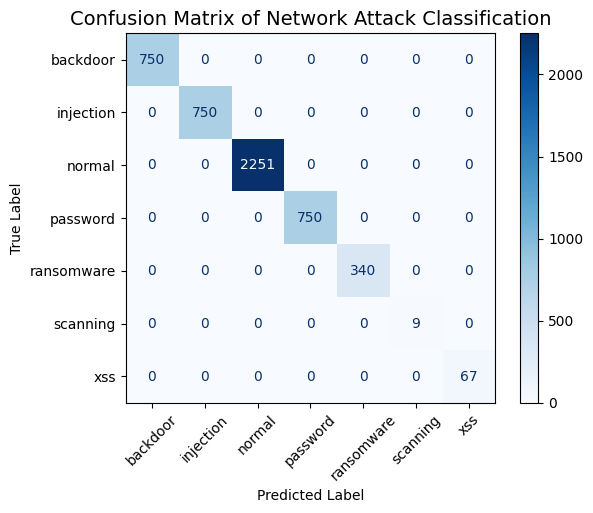


Classification Report:

              precision    recall  f1-score   support

    backdoor       1.00      1.00      1.00       750
   injection       1.00      1.00      1.00       750
      normal       1.00      1.00      1.00      2251
    password       1.00      1.00      1.00       750
  ransomware       1.00      1.00      1.00       340
    scanning       1.00      1.00      1.00         9
         xss       1.00      1.00      1.00        67

    accuracy                           1.00      4917
   macro avg       1.00      1.00      1.00      4917
weighted avg       1.00      1.00      1.00      4917



In [246]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Predict on test set
y_pred_probs = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix with class labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

# Plot as heatmap
plt.figure(figsize=(10, 8))
disp.plot(cmap='Blues', xticks_rotation=45, values_format='d', colorbar=True)
plt.title("Confusion Matrix of Network Attack Classification", fontsize=14)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.grid(False)
plt.show()

# Optionally print detailed report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))


In [249]:
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf

def predict_attack_type(new_data):
    """
    Predicts the network attack type for new data.

    Args:
        new_data (dict): A dictionary containing the new data with keys:
                         'current_temperature', 'thermostat_status', 'hour',
                         'day', 'month', 'weekday'.

    Returns:
        str: The predicted network attack type.
    """
    # Load the scaler and model
    scaler = joblib.load('scaler.pkl')
    model = tf.keras.models.load_model('final_network_model.h5')
    le = joblib.load('type_encoder.pkl')


    # Create a DataFrame from the new data
    new_df = pd.DataFrame([new_data])

    # Preprocess the new data
    # Scale numerical features - Assuming current_temperature, thermostat_status, hour, day, month, weekday need scaling.
    features = ['current_temperature', 'thermostat_status', 'hour', 'day', 'month', 'weekday']
    new_data_scaled = scaler.transform(new_df[features])


    # Make prediction
    prediction_probs = model.predict(new_data_scaled)
    predicted_class_index = np.argmax(prediction_probs, axis=1)[0]

    # Decode the predicted class
    predicted_attack_type = le.inverse_transform([predicted_class_index])[0]

    return predicted_attack_type

# Example usage:
new_sample = {'current_temperature': 	31.141066	, 'thermostat_status':1, 'hour': 9, 'day': 28, 'month': 4, 'weekday': 6}
predicted_type = predict_attack_type(new_sample)
print(f"The predicted attack type is: {predicted_type}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
The predicted attack type is: backdoor


In [248]:
df[df['type']==0]

,current_temperature,thermostat_status,label,type,hour,day,month,weekday
800,31.141066,1,1,0,9,28,4,6
801,28.541464,1,1,0,9,28,4,6
802,29.657242,1,1,0,9,28,4,6
803,31.033298,1,1,0,9,28,4,6
804,28.057815,1,1,0,9,28,4,6
...,...,...,...,...,...,...,...,...
5795,27.045088,1,1,0,22,28,4,6
5796,27.536030,1,1,0,22,28,4,6
5797,26.767937,1,1,0,22,28,4,6
5798,26.586098,1,1,0,22,28,4,6


In [250]:
df['type'].value_counts()

,count
type,
2,15000
1,5000
0,5000
3,5000
4,2264
6,449
5,61


In [126]:

# count
# type
# normal	15000
# injection	5000
# backdoor	5000
# password	5000
# ransomware	2264
# xss	449
# scanning	61




np.int64(0)